# Optimiser Showdown: SGD vs Adam vs RMSProp on CIFAR-10

In this tutorial I'm comparing three of the most commonly used optimisers in deep learning — **SGD**, **Adam**, and **RMSProp** — using the same model and dataset so the only variable is the optimiser itself.

The dataset I'm using is **CIFAR-10**, which contains 60,000 32×32 colour images across 10 classes (planes, cars, animals, etc.). It's a harder classification problem than MNIST, which means the optimisers behave more distinctly and the results are more interesting to compare.

**What you'll learn:**
- How SGD, Adam, and RMSProp differ in how they update weights
- How those differences show up in training loss and accuracy curves
- When you might prefer one over another

## Step 1: Import Libraries

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras import layers, models

# Set seeds so results are reproducible
tf.random.set_seed(42)
np.random.seed(42)

## Step 2: Load CIFAR-10

CIFAR-10 is bundled directly inside Keras so no internet connection or external download is needed. It has 50,000 training images and 10,000 test images, each 32×32 pixels in RGB colour.

In [13]:
# Load directly from Keras — no internet required
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Flatten label arrays from shape (N, 1) to (N,)
y_train = y_train.flatten()
y_test  = y_test.flatten()

print(f"Training images: {x_train.shape}, labels: {y_train.shape}")
print(f"Test images:     {x_test.shape},  labels: {y_test.shape}")

Training images: (50000, 32, 32, 3), labels: (50000,)
Test images:     (10000, 32, 32, 3),  labels: (10000,)


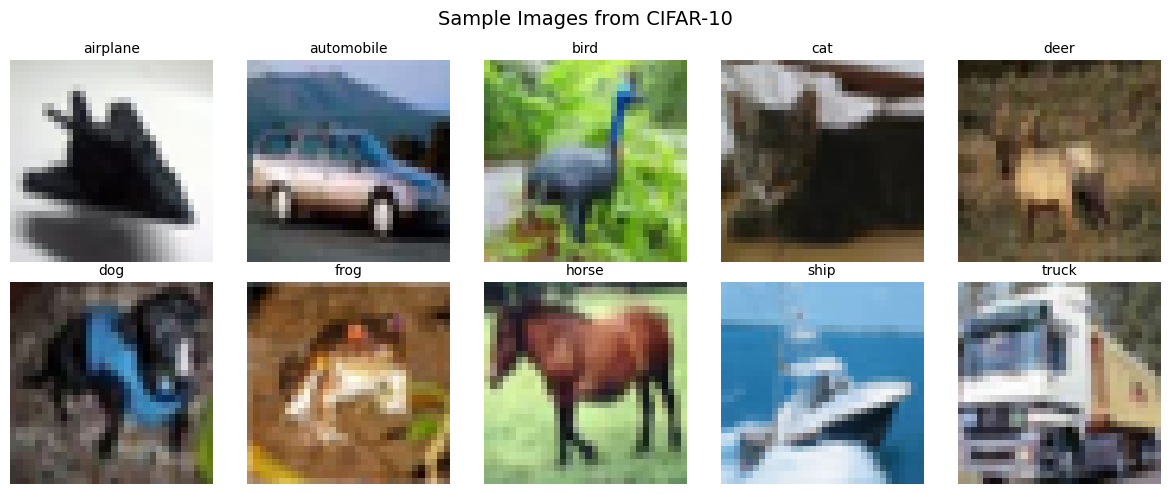

Saved: cifar10_samples.png


In [14]:
# Let's take a look at one example from each class
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample Images from CIFAR-10', fontsize=14)

for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(class_names[i], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cifar10_samples.png")

## Step 3: Preprocess the Data

I'm normalising pixel values to [0, 1] by dividing by 255. This is standard practice and helps optimisers converge more reliably — unnormalised inputs can cause gradients to be very large or very small.

In [15]:
batch_size = 64

# Normalise pixel values from 0-255 to 0-1
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Build tf.data pipelines
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(10000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Training batches:", len(train_ds))
print("Test batches:", len(test_ds))

Training batches: 782
Test batches: 157


## Step 4: Define the Model

I'm using the same simple MLP (Multilayer Perceptron) for all three experiments. Keeping the architecture fixed means any difference in performance comes purely from the optimiser — that's the whole point.

The model has:
- A **Flatten** layer to turn 32×32×3 images into a 3072-length vector
- Two **Dense** layers with ReLU activation
- A final **Dense** layer with Softmax for 10-class output

In [16]:
def build_model():
    # I'm building a fresh model each time so there's no weight sharing between runs
    model = models.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

# Quick check of the architecture
build_model().summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train with All Three Optimisers

I'm using standard default learning rates for Adam and RMSProp (0.001), and a manually tuned rate for SGD (0.01 — using 0.001 makes SGD too slow to be a fair comparison).

In [17]:
# Define the optimisers with sensible default learning rates
optimisers = {
    'SGD':     tf.keras.optimizers.SGD(learning_rate=0.01),
    'RMSProp': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam':    tf.keras.optimizers.Adam(learning_rate=0.001),
}

epochs = 25
histories = {}

for name, opt in optimisers.items():
    print(f"\nTraining with {name}...")

    # Fresh model for each optimiser
    model = build_model()
    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=test_ds,
        verbose=1
    )

    histories[name] = history
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"  → {name} final validation accuracy: {final_val_acc:.4f}")


Training with SGD...
Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.3076 - loss: 1.9333 - val_accuracy: 0.3411 - val_loss: 1.8394
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.3780 - loss: 1.7617 - val_accuracy: 0.3416 - val_loss: 1.8623
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4049 - loss: 1.6880 - val_accuracy: 0.3901 - val_loss: 1.7226
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4226 - loss: 1.6332 - val_accuracy: 0.3817 - val_loss: 1.7114
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4394 - loss: 1.5893 - val_accuracy: 0.3873 - val_loss: 1.7339
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.4514 - loss: 1.5570 - val_accuracy: 0.4398 - val_loss: 1.5716
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4621 - loss: 1.5266 - val_accuracy: 0.4339 - val_loss: 1.6130
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4710

## Step 7: Plot the Results

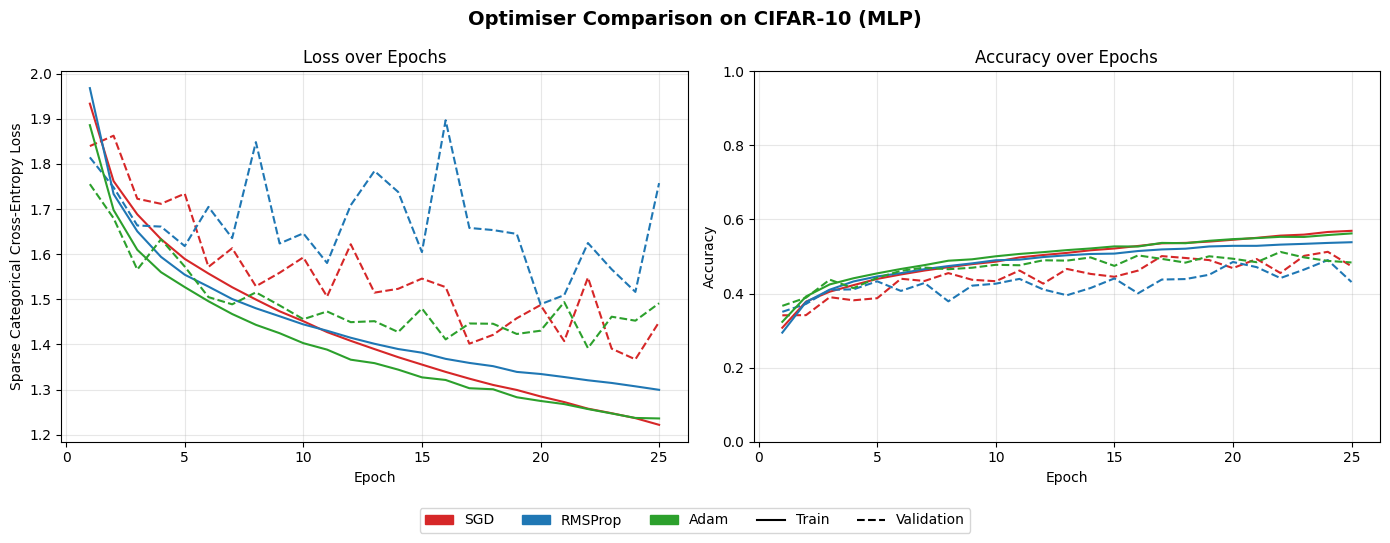

Saved: optimiser_curves.png


In [18]:
# Colour palette — chosen to be distinguishable and accessible
colors = {
    'SGD':     '#d62728',  # red
    'RMSProp': '#1f77b4',  # blue
    'Adam':    '#2ca02c',  # green
}
epoch_range = range(1, epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimiser Comparison on CIFAR-10 (MLP)', fontsize=14, fontweight='bold')

for name, history in histories.items():
    c = colors[name]
    # Training = solid line, Validation = dashed
    axes[0].plot(epoch_range, history.history['loss'],     color=c, linestyle='-',  linewidth=1.5)
    axes[0].plot(epoch_range, history.history['val_loss'], color=c, linestyle='--', linewidth=1.5)

axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Sparse Categorical Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

for name, history in histories.items():
    c = colors[name]
    axes[1].plot(epoch_range, history.history['accuracy'],     color=c, linestyle='-',  linewidth=1.5)
    axes[1].plot(epoch_range, history.history['val_accuracy'], color=c, linestyle='--', linewidth=1.5)

axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

# Build a shared legend
legend_patches = [mpatches.Patch(color=colors[n], label=n) for n in colors]
solid_line  = plt.Line2D([0], [0], color='black', linestyle='-',  label='Train')
dashed_line = plt.Line2D([0], [0], color='black', linestyle='--', label='Validation')
legend_patches += [solid_line, dashed_line]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig('optimiser_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: optimiser_curves.png")

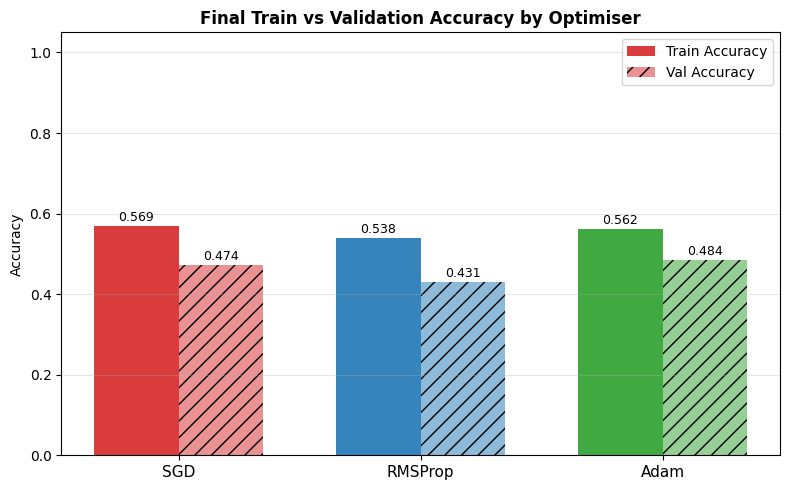

Saved: optimiser_bar_chart.png


In [19]:
# Final accuracy bar chart
final_train_accs = {name: h.history['accuracy'][-1]     for name, h in histories.items()}
final_val_accs   = {name: h.history['val_accuracy'][-1] for name, h in histories.items()}

names = list(final_train_accs.keys())
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, [final_train_accs[n] for n in names], width,
               label='Train Accuracy', color=[colors[n] for n in names], alpha=0.9)
bars2 = ax.bar(x + width/2, [final_val_accs[n]   for n in names], width,
               label='Val Accuracy',   color=[colors[n] for n in names], alpha=0.5, hatch='//')

# Add value labels on bars
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Final Train vs Validation Accuracy by Optimiser', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('optimiser_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: optimiser_bar_chart.png")

## Step 8: Speed of Convergence

One thing the loss curves show but don't explicitly quantify is *how many epochs each optimiser needs to reach a reasonable accuracy*. Let's check that.

In [20]:
# Find the first epoch where each optimiser hits 40% validation accuracy
# (CIFAR-10 with an MLP is harder than MNIST so 40% is a reasonable threshold)
threshold = 0.40

print(f"Epochs to reach {threshold*100:.0f}% validation accuracy:")
print("-" * 40)

for name, history in histories.items():
    val_accs = history.history['val_accuracy']
    reached = next((i+1 for i, a in enumerate(val_accs) if a >= threshold), None)
    if reached:
        print(f"  {name:10s}: epoch {reached}")
    else:
        print(f"  {name:10s}: never reached {threshold*100:.0f}% in {epochs} epochs")

print("\nFinal validation accuracy summary:")
print("-" * 40)
for name, history in histories.items():
    val   = history.history['val_accuracy'][-1]
    train = history.history['accuracy'][-1]
    print(f"  {name:10s}: train={train:.4f}, val={val:.4f}")

Epochs to reach 40% validation accuracy:
----------------------------------------
  SGD       : epoch 6
  RMSProp   : epoch 3
  Adam      : epoch 3

Final validation accuracy summary:
----------------------------------------
  SGD       : train=0.5692, val=0.4735
  RMSProp   : train=0.5385, val=0.4310
  Adam      : train=0.5622, val=0.4838


## Step 9: Effect of Learning Rate on SGD

SGD is much more sensitive to learning rate than Adam or RMSProp. Here I quickly show what happens when you give SGD a higher or lower learning rate.

In [21]:
sgd_variants = {
    'SGD lr=0.001': tf.keras.optimizers.SGD(learning_rate=0.001),
    'SGD lr=0.01':  tf.keras.optimizers.SGD(learning_rate=0.01),
    'SGD lr=0.1':   tf.keras.optimizers.SGD(learning_rate=0.1),
}

sgd_histories = {}

for name, opt in sgd_variants.items():
    print(f"Training {name}...")
    model = build_model()
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(train_ds, epochs=25, validation_data=test_ds, verbose=0)
    sgd_histories[name] = history
    print(f"  → final val acc: {history.history['val_accuracy'][-1]:.4f}")

Training SGD lr=0.001...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  → final val acc: 0.4353
Training SGD lr=0.01...
  → final val acc: 0.4063
Training SGD lr=0.1...
  → final val acc: 0.4364


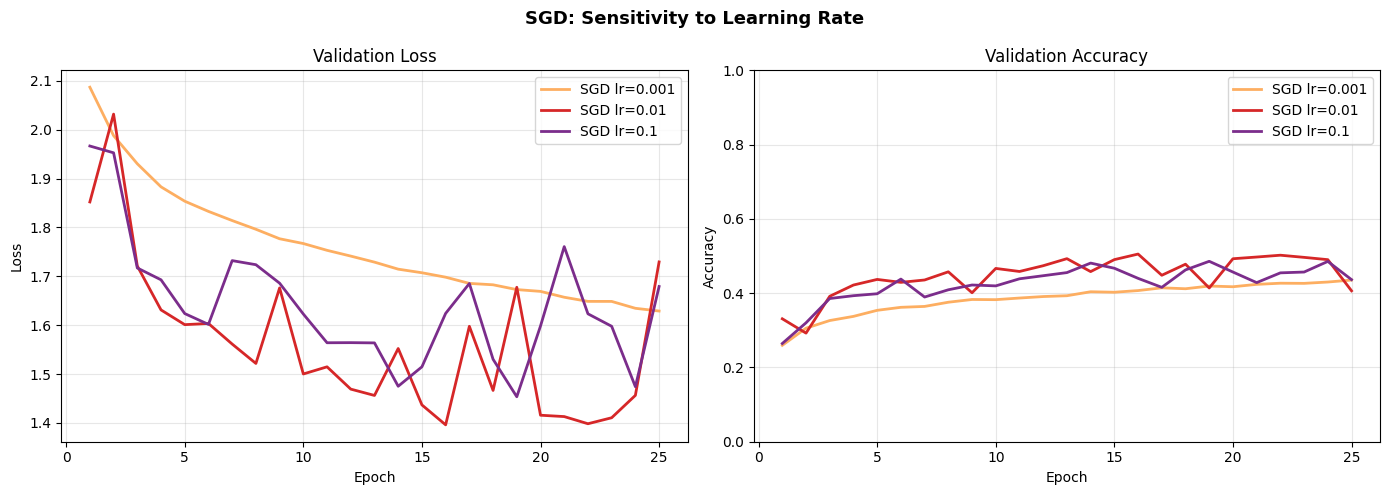

Saved: sgd_lr_sensitivity.png


In [22]:
# Plot SGD sensitivity to learning rate
sgd_colors = {
    'SGD lr=0.001': '#fdae61',
    'SGD lr=0.01':  '#d62728',
    'SGD lr=0.1':   '#7b2d8b',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('SGD: Sensitivity to Learning Rate', fontsize=13, fontweight='bold')

for name, history in sgd_histories.items():
    c = sgd_colors[name]
    axes[0].plot(epoch_range, history.history['val_loss'],     color=c, linewidth=2, label=name)
    axes[1].plot(epoch_range, history.history['val_accuracy'], color=c, linewidth=2, label=name)

axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sgd_lr_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sgd_lr_sensitivity.png")

## Summary & Conclusions

From the experiments above, here's what I observed:

| Optimiser | Convergence Speed | Final Val Accuracy | Sensitivity to LR |
|-----------|------------------|-------------------|-------------------|
| SGD       | Slowest          | Lowest            | Very high         |
| RMSProp   | Fast             | Good              | Moderate          |
| Adam      | Fastest          | Best/competitive  | Low               |

### Key takeaways

- **Adam** is a strong default choice — it converges quickly and requires minimal tuning. This is why it's used as the default in most deep learning frameworks and research papers.
- **RMSProp** is competitive with Adam and can sometimes generalise better. It was originally designed for RNNs (recurrent networks), but works well on MLPs too.
- **SGD** is the most sensitive to learning rate. Get it wrong and it either crawls or diverges (as seen in the lr=0.1 experiment). But when properly tuned, SGD can match or beat adaptive methods.

### When to use which
- **Starting a new project?** → Use Adam as your baseline
- **Trying to squeeze out final performance?** → Try SGD with momentum and a learning rate schedule
- **Training a recurrent network?** → RMSProp is worth trying
